# Getting Started with metaheuristic‑designer

We’ll minimise the `Sphere` function with a Genetic Algorithm (GA).
The library is imported as `mhd`; concrete components come from subpackages,
base classes and factory functions from the top‑level.

In [1]:
import metaheuristic_designer as mhd
from metaheuristic_designer.benchmarks import Sphere
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Define the objective function

`Sphere` in 3 dimensions, minimisation mode.

In [2]:
DIM = 3
objfunc = Sphere(DIM, mode="min")

## 2. Reproducible random seed

In [3]:
rng = mhd.check_random_state(43)

## 3. Assemble the GA strategy

- Uniform initializer between -10 and 10, population size 100.
- Gaussian mutation (one component, std=0.1).
- Uniform crossover.
- Parent selection: torunament that picks 25 individuals in tournaments of size 3.
- Survivor selection: elitism, keeping 10 best parents.
- Crossover/mutation probabilities: 0.9 / 0.3.

In [4]:
strategy = mhd.strategies.GA(
    initializer=mhd.initializers.UniformInitializer(DIM, -10, 10, pop_size=100, random_state=rng),
    mutation_op=mhd.operators.create_operator("mutation.gaussian_mutation", N=3, F=0.1, random_state=rng),
    crossover_op=mhd.operators.create_operator("crossover.uniform", random_state=rng),
    parent_sel=mhd.parent_selection.create_parent_selection("tournament", amount=50, tournament_size=3, random_state=rng),
    survivor_sel=mhd.survivor_selection.create_survivor_selection("elitism", amount=25, random_state=rng),
    mutation_prob=0.3,
    crossover_prob=0.9,
    random_state=rng,
)

## 4. Run the algorithm

Stop after 100 generations (`stop_cond="ngen"`).

In [5]:
algo = mhd.algorithms.Algorithm(objfunc, strategy, ngen=100, stop_cond="ngen", reporter="tqdm")
population = algo.optimize()

  0%|          |   0% [00:00<?, ?it/s]

## 5. Inspect the result

In [6]:
solution, fitness = population.best_solution(problem_space=True)
print(f"Best fitness: {fitness}")
print(f"Best solution: {solution}")

Best fitness: 7.7001653350437e-05
Best solution: [ 0.00040882 -0.00130893 -0.00866725]


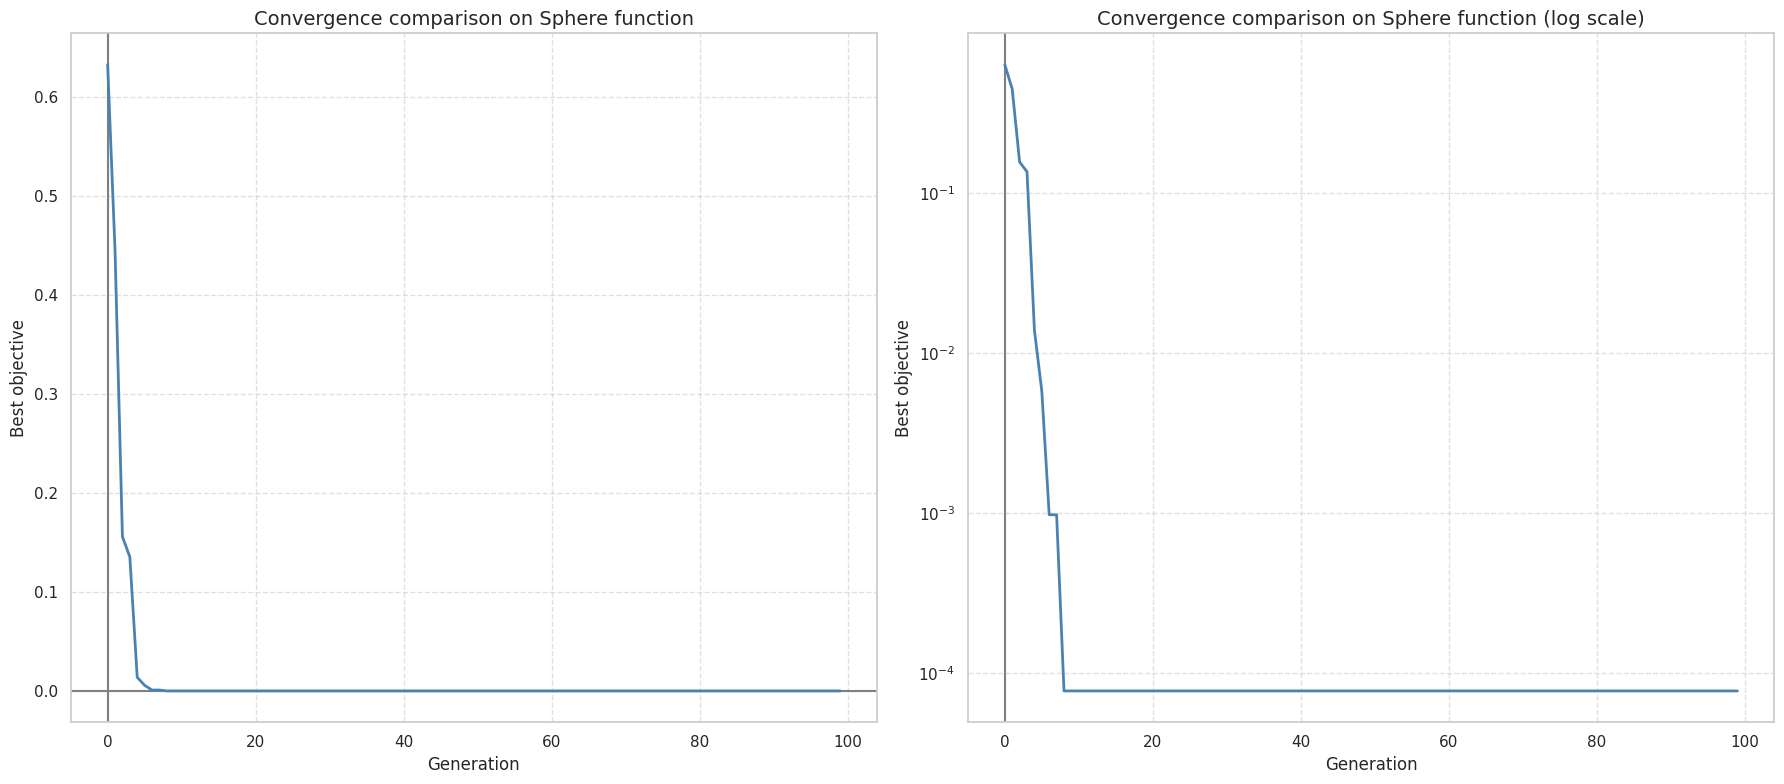

In [9]:
# Dataframe with the tracked best objective value across generations.
history_data = algo.history_tracker.to_pandas()

# Plotting functionality.
# sns.set_theme(style="whitegrid")
# ax = sns.lineplot(history_data, x="iteration", y="best_objective", linewidth=2, color="steelblue", zorder=10)
# ax.set_xlabel("Generation", fontsize=12)
# ax.set_ylabel("Best objective", fontsize=12)
# ax.set_title("Convergence Plot", fontsize=14)
# plt.grid(linestyle="--", alpha=0.6)
# ax.axhline(0, color="grey")
# ax.axvline(0, color="grey")
# plt.tight_layout()
# plt.show()
# Plot
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Normal scale plot
sns.lineplot(history_data, x="iteration", y="best_objective", linewidth=2, color="steelblue", ax=ax1, zorder=10)
ax1.set_xlabel("Generation", fontsize=12)
ax1.set_ylabel("Best objective", fontsize=12)
ax1.set_title("Convergence comparison on Sphere function", fontsize=14)
ax1.grid(linestyle="--", alpha=0.6, zorder=-12)
ax1.axhline(0, color="grey")
ax1.axvline(0, color="grey")

# Log scale plot
sns.lineplot(history_data, x="iteration", y="best_objective", linewidth=2, color="steelblue", ax=ax2, zorder=10)
ax2.set_xlabel("Generation", fontsize=12)
ax2.set_ylabel("Best objective", fontsize=12)
ax2.set_title("Convergence comparison on Sphere function (log scale)", fontsize=14)
ax2.set_yscale('log')          # Sphere spans orders of magnitude
ax2.grid(linestyle="--", alpha=0.6)
ax2.axhline(0, color="grey")
ax2.axvline(0, color="grey")

plt.tight_layout()
plt.show()